In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity

In [22]:
import emcee
import pandas as pd
from astropy.table import Table
import corner
import scipy

# L11

### Data

In [23]:
file='transient.npy'
data=np.load(file)
N=10
t=data[:,0]
flux=data[:,1]
err=data[:,2]

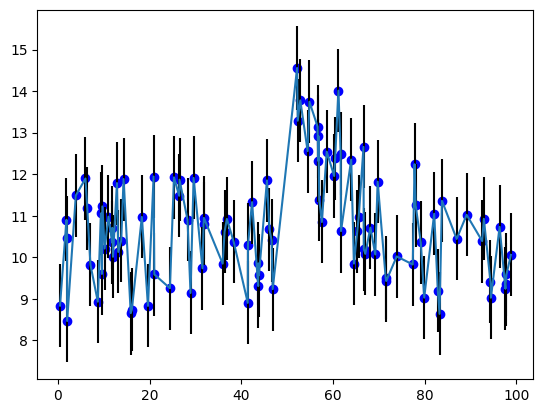

In [24]:
plt.scatter(t,flux, c='b')
plt.errorbar(t,flux, yerr=err, ecolor='k');

### Fit by eye

In [25]:
def model(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

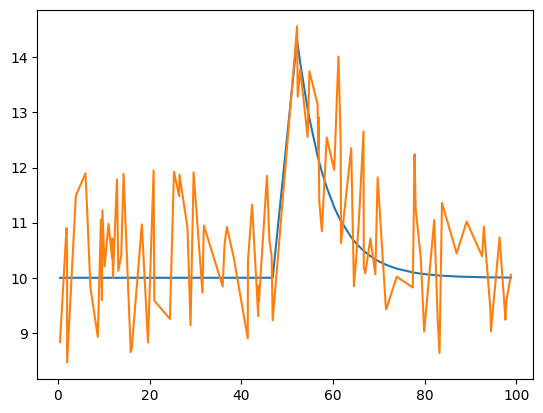

In [26]:
y=model([6,10,50,0.15],t)
plt.plot(t,y)
plt.plot(t,flux);

### MCMC

In [27]:
def LogLikelihood(theta, data, model): 
    A,b,t0,alpha=theta
    t=data[:,0]
    flux=data[:,1]
    err=data[:,2]
    return -0.5 * np.sum((flux-model(theta,t))**2 / err**2)

In [28]:
theta=[5,10,50,0.1]
logL=LogLikelihood(theta,data,model)

In [29]:
def Logprior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return 0.0 + 0.0 + 0.0 - np.log(alpha)
    return -np.inf

def logPosterior(theta, data, model):
    return LogLikelihood(theta, data, model) + Logprior(theta)

In [30]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

In [31]:
ndim = 4  
nwalkers = 20  
burn = 10000  
nsteps = 100000 

starting_guesses = np.array([6,10,50,0.15]) + 1e-1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=[data, model])
sampler.run_mcmc(starting_guesses, nsteps)
 
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


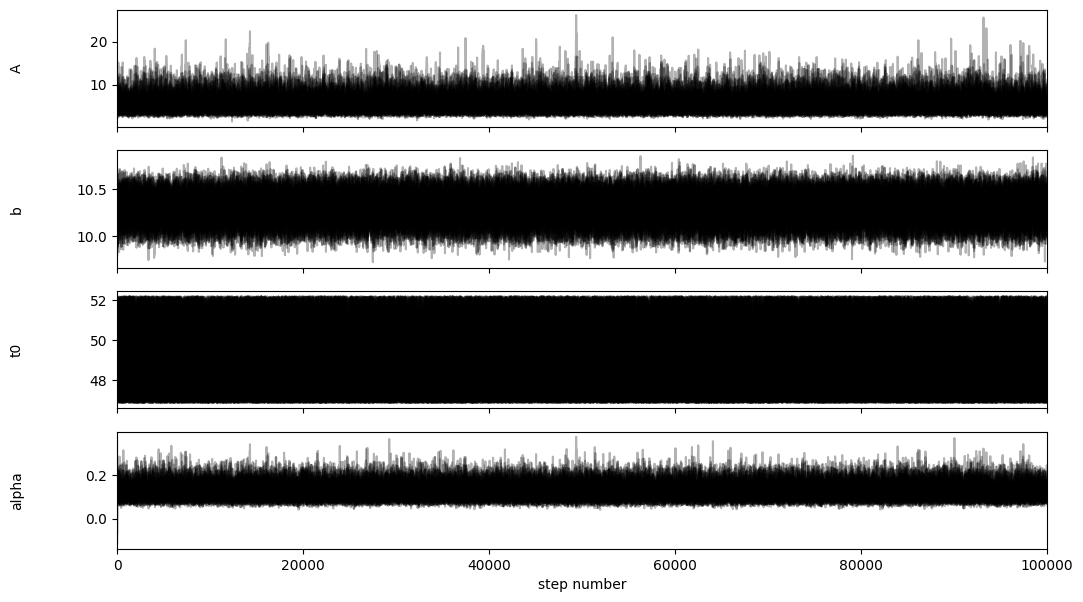

In [32]:
fig, axes = plt.subplots(4, figsize=(12, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [33]:
tau = sampler.get_autocorr_time()
print(tau)

[82.85484462 59.58013418 80.90354781 69.43535244]


In [34]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(24320, 4)


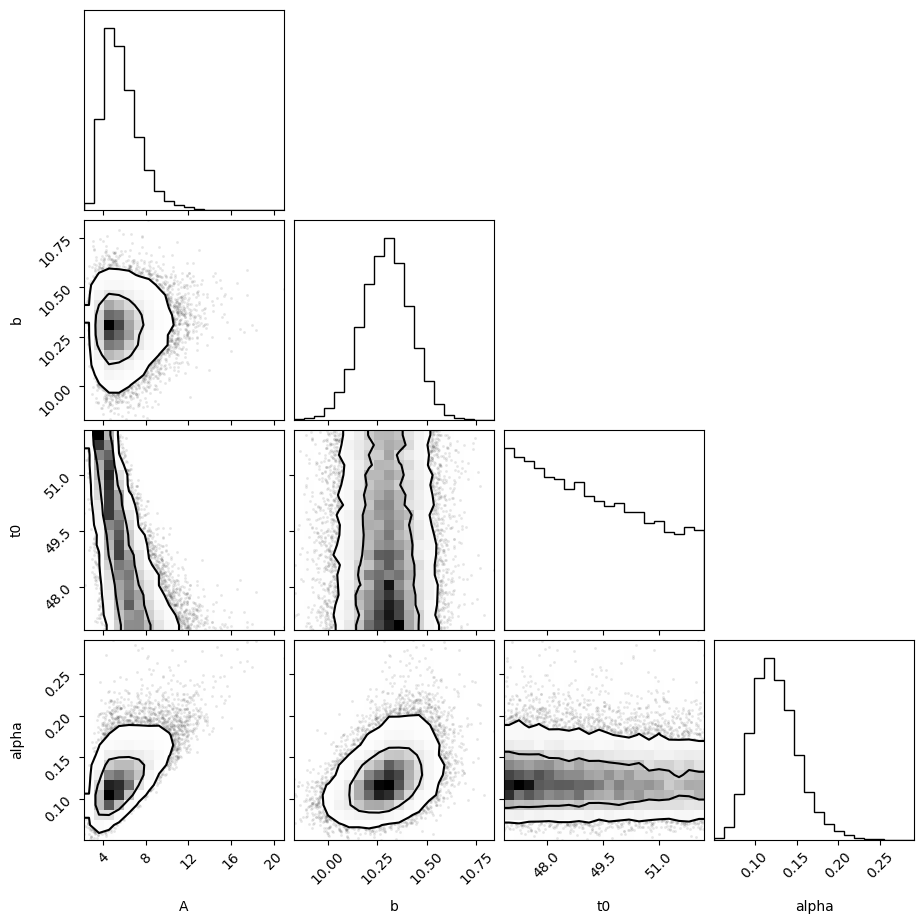

In [35]:
fig = corner.corner(
    flat_samples, labels=labels, levels=[0.68,0.95]
);

In [50]:
samples= flat_samples[np.random.choice(len(flat_samples),size=30)]

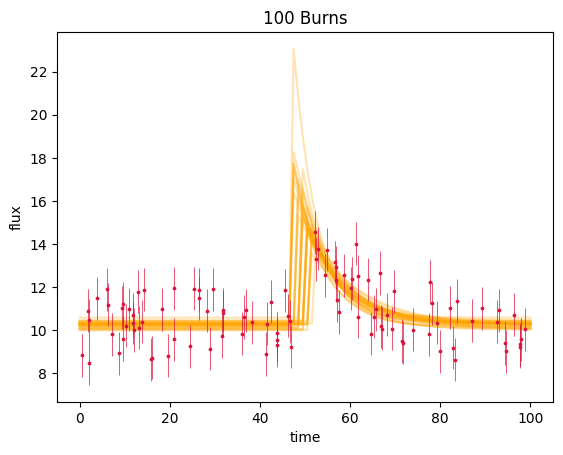

In [57]:
tgrid=np.linspace(0,100,100)

for theta in samples:

    ygrid =  model(theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='orange')
    
plt.errorbar(t,flux,yerr=err,fmt='o',c='crimson',lw=0.5, markersize=1.7)
plt.xlabel("time")
plt.ylabel("flux")
plt.title("100 Burns");

In [58]:
for i,l in enumerate(labels):
    low,med, up = np.percentile(flat_samples[:,i],[5,50,95]) 
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.405307037097396 +3.3948665194444025 -1.8182224303846213
b   10.297658614628418 +0.19601017873792337 -0.20526422761612118
t0   49.07660017416565 +2.756488067732036 -2.0135512686209225
alpha   0.12231700013093183 +0.053456501723345345 -0.03697132205522505


# L12

### Nested Sampling

In [62]:
import dynesty

### Burst

In [63]:
def Logpriornew(u):
    u[0]=u[0]*50
    u[1]=u[1]*50
    u[2]=u[2]*100
    u[3]=np.exp(u[3]*10-5)
    return u
                   
def LogPosterior(theta,data, model=model):
    return LogLikelihood(theta,data, model) + Logprior(theta)

In [64]:
def LogLikelihood(theta, model=model):
    t=data[:,0]
    flux=data[:,1]
    err=data[:,2]
    return -0.5 * np.sum((flux-model(theta,t))**2 / err**2)

In [65]:
ndim=4

In [66]:
sampler = dynesty.NestedSampler(LogLikelihood, Logpriornew, ndim)
sampler.run_nested()
sresults = sampler.results

C:\Users\insta\AppData\Local\Temp\ipykernel_31080\1725545783.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
C:\Users\insta\AppData\Local\Temp\ipykernel_31080\1725545783.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
1824it [00:01, 1276.46it/s, bound: 0 | nc: 6 | ncall: 17130 | eff(%): 10.648 | loglstar:   -inf < -163.609 <    inf | logz: -171.986 +/-  0.125 | dlogz: 91.571 >  0.509]  C:\Users\insta\AppData\Local\Temp\ipykernel_31080\1725545783.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
C:\Users\insta\AppData\Local\Temp\ipykernel_31080\1725545783.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
1958it [00:01, 615.38it/s, bound: 2 | nc: 7 | ncall: 19333 | eff(%): 10.128 | loglstar:   -inf < -137.449 <    inf | logz: -145.684 +/-  0.121 | dlogz: 64.914 >  0.509

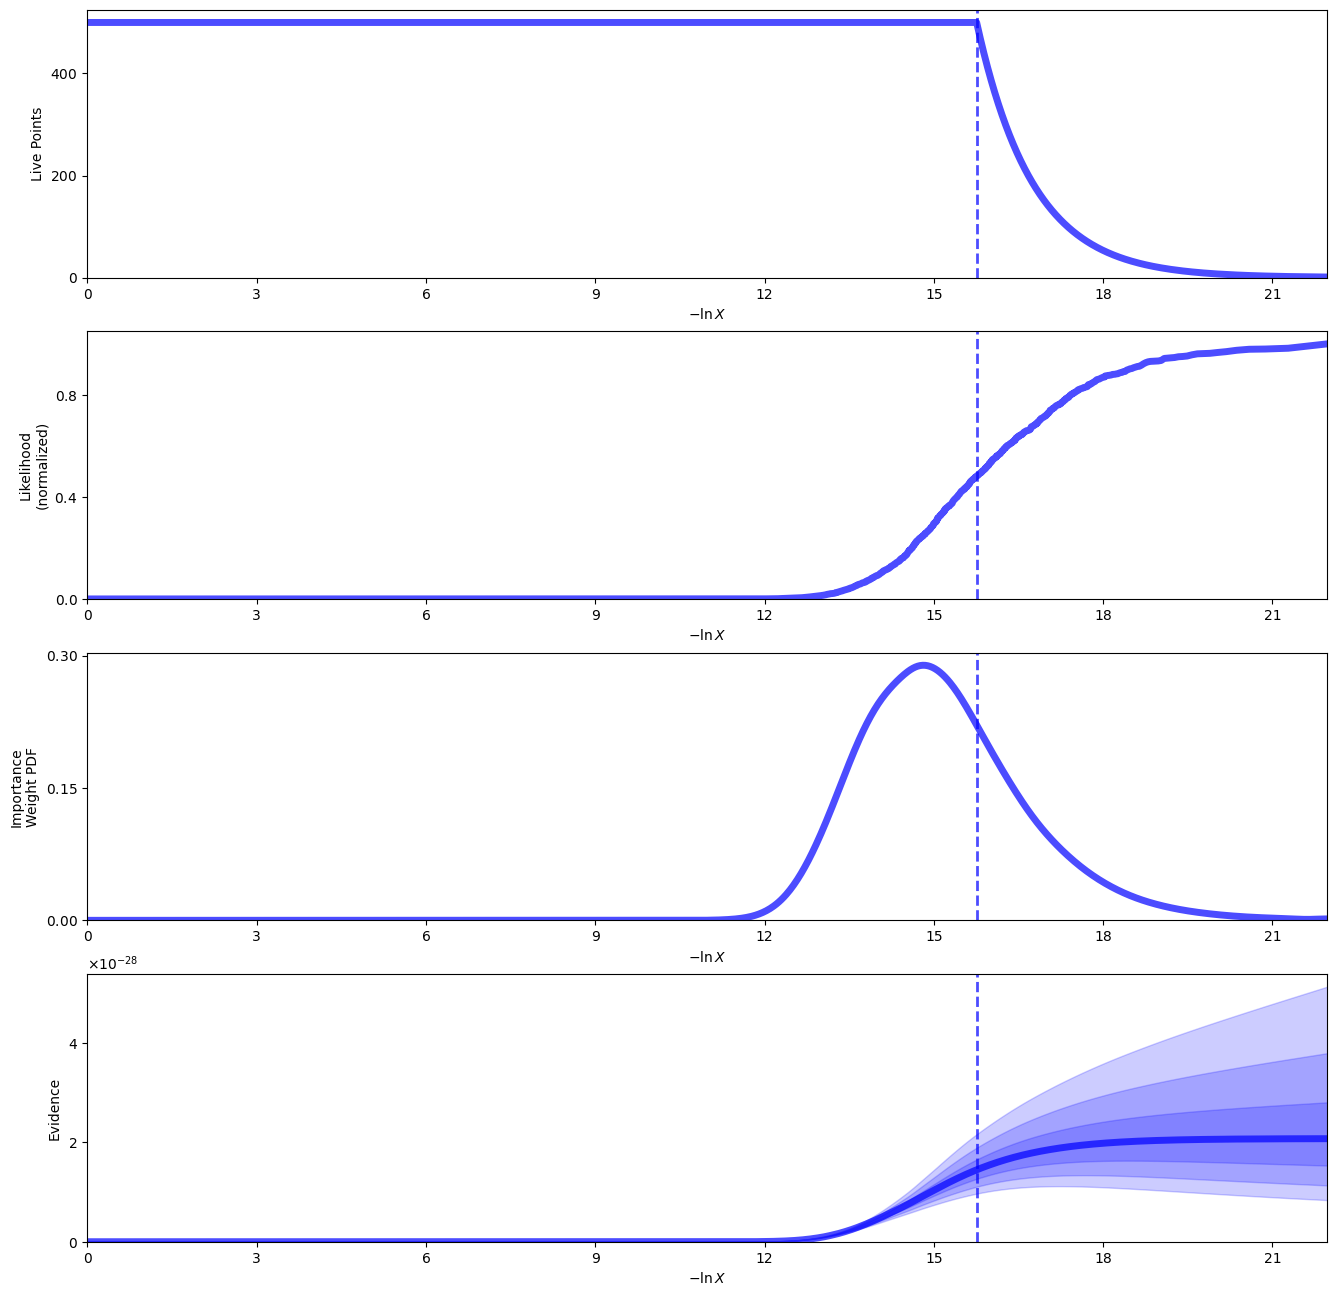

In [67]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

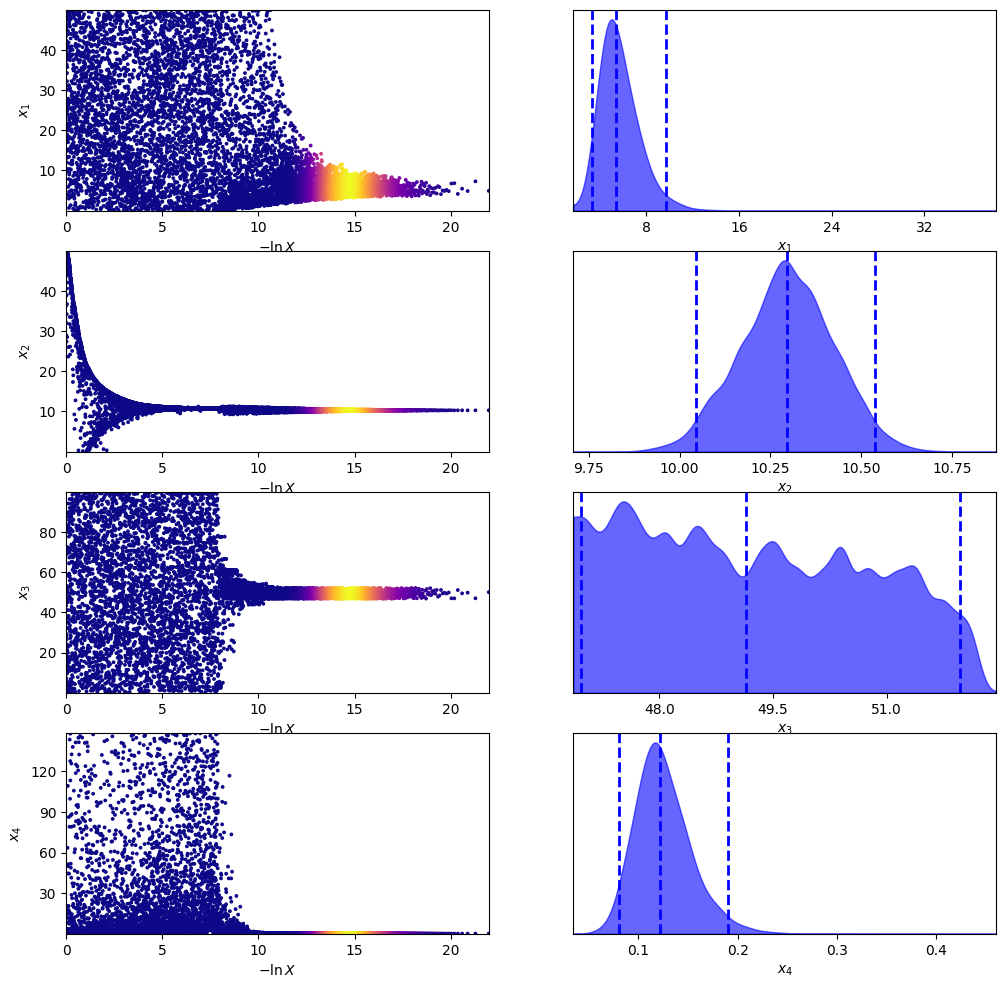

In [68]:
tfig, taxes = dyplot.traceplot(sresults)

In [69]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 2.0765776927217538e-28
68% parameter credible regions are:
 [[4.179877311474019, 7.162461618629761], [10.166570938215497, 10.422487897381576], [47.53713342069272, 51.05328582257064], [0.09924999395312575, 0.15050763914569215]]

Mean and covariance of parameters are: [ 5.66751136 10.29473289 49.24764487  0.12504846]
[[ 2.67329966e+00  1.25516586e-02 -1.64951244e+00  2.62036572e-02]
 [ 1.25516586e-02  1.61492570e-02 -2.32640569e-03  1.43473778e-03]
 [-1.64951244e+00 -2.32640569e-03  2.26622746e+00 -1.48330074e-03]
 [ 2.62036572e-02  1.43473778e-03 -1.48330074e-03  7.83675127e-04]]


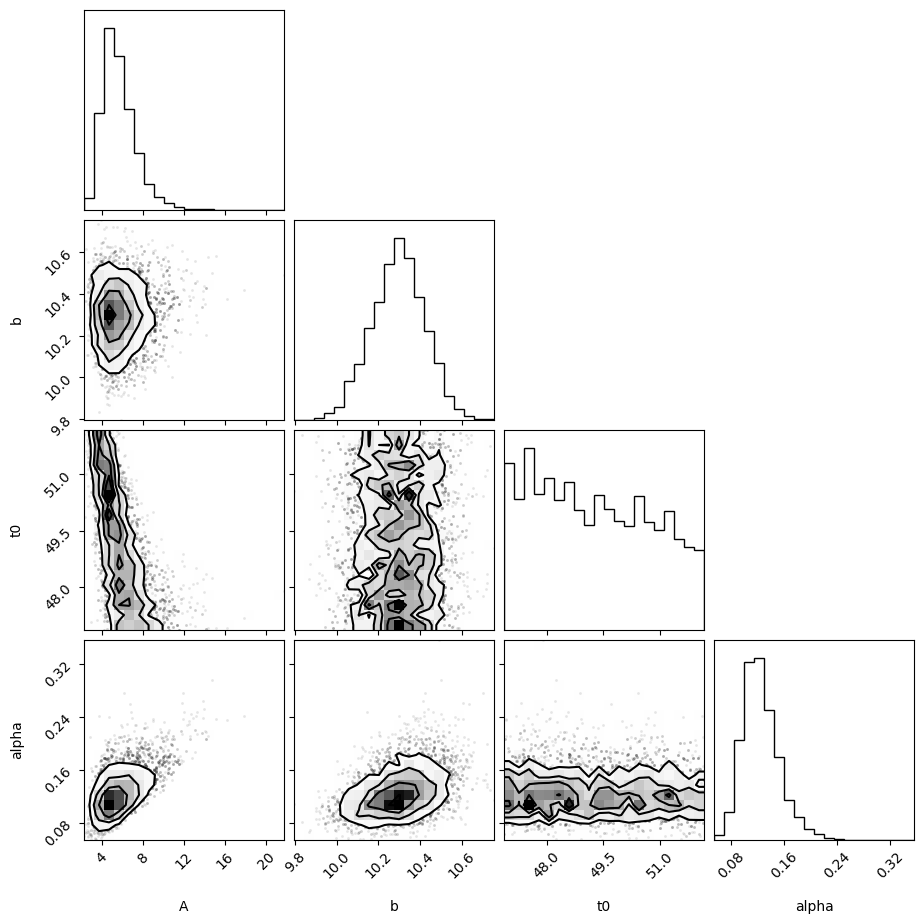

In [70]:
import corner
samples_equal = dyfunc.resample_equal(samples, weights)
labels = ["A","b","t0","alpha"]
corner.corner(samples_equal, labels=labels);

### Gaussian

In [71]:
def model(theta,t):
    A,b,t0,sigmaW=theta 
    return b+A*np.exp(-(t-t0)**2/(2*sigmaW**2))

In [72]:
def LogLikelihood(theta, model=model):
    t=data[:,0]
    flux=data[:,1]
    err=data[:,2]
    return -0.5 * np.sum((flux-model(theta,t))**2 / err**2)

In [73]:
def Logpriornew(u):
    u[0]=u[0]*50
    u[1]=u[1]*50
    u[2]=u[2]*100
    u[3]=np.exp(u[3]*4-2)
    return u

In [74]:
sampler = dynesty.NestedSampler(LogLikelihood, Logpriornew, ndim)
sampler.run_nested()
sresults2 = sampler.results

4186it [00:36, 28.84it/s, bound: 114 | nc: 12 | ncall: 81889 | eff(%):  5.112 | loglstar:   -inf < -86.343 <    inf | logz: -94.490 +/-  0.117 | dlogz: 31.223 >  0.509] C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex poste

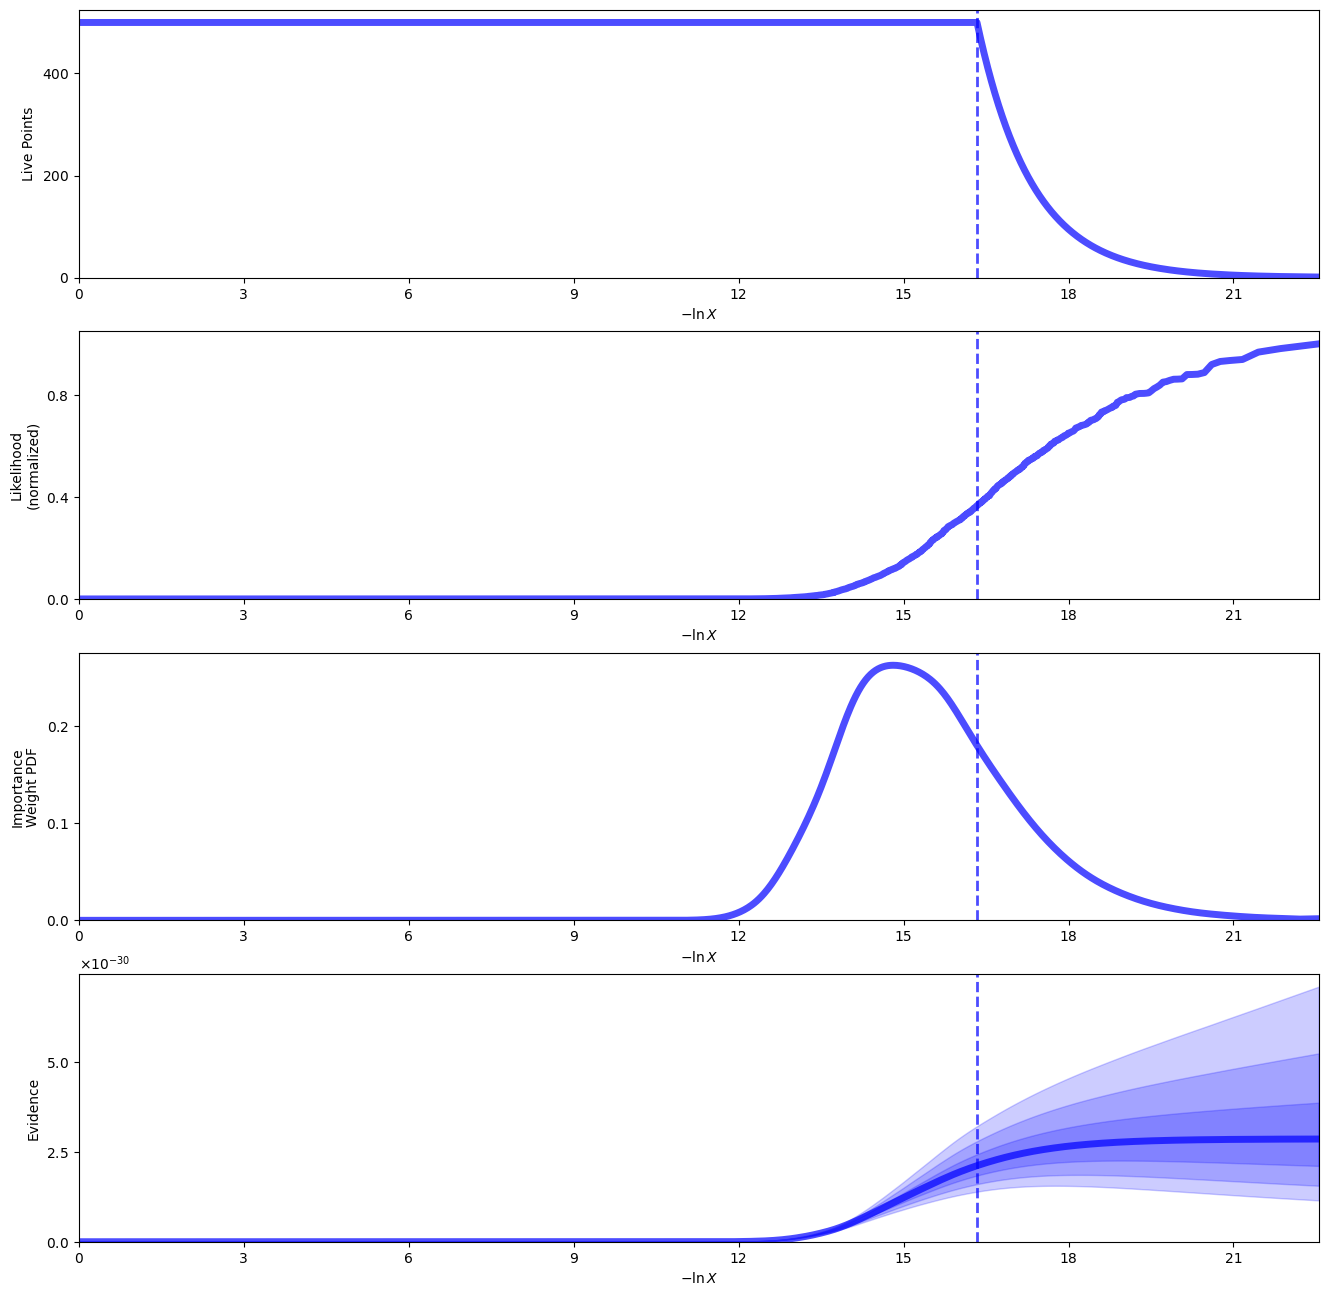

In [75]:
rfig, raxes = dyplot.runplot(sresults2)

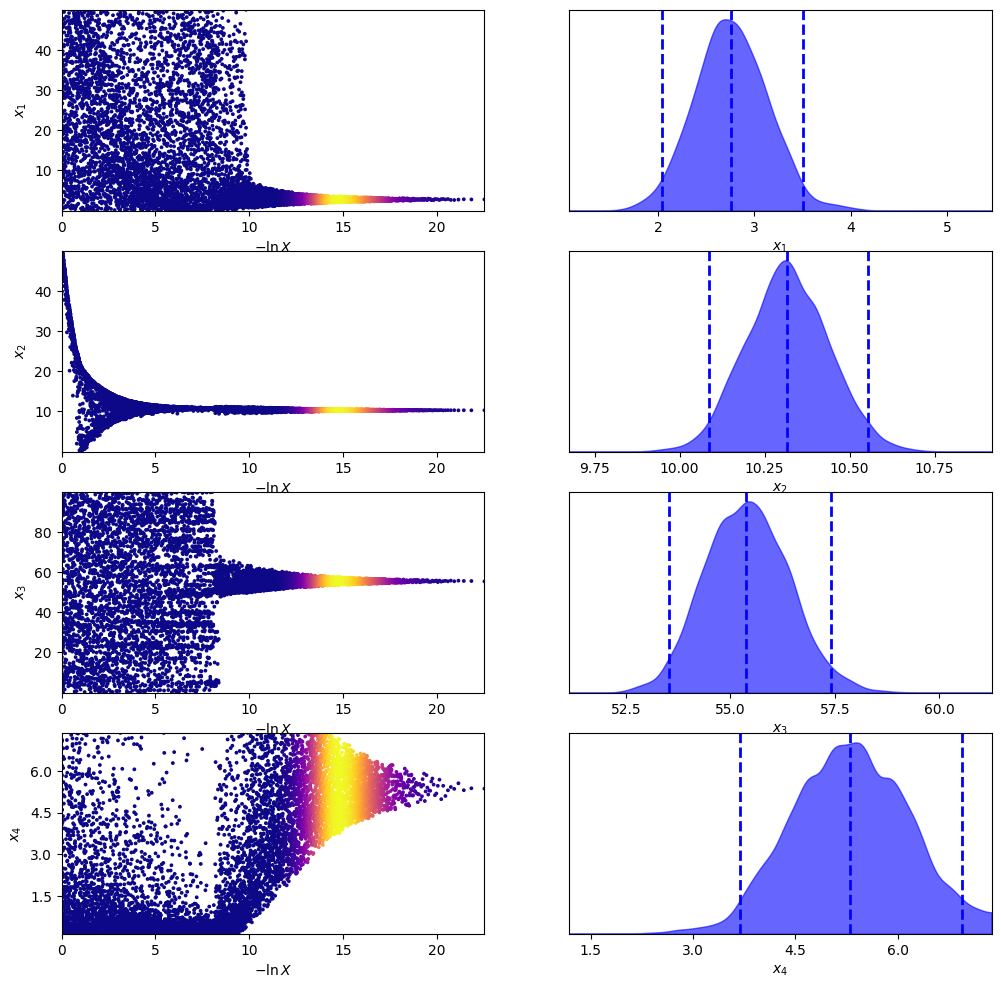

In [76]:
tfig, taxes = dyplot.traceplot(sresults2)

In [77]:
# Extract sampling results.
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights


evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 2.8536053836423188e-30
68% parameter credible regions are:
 [[2.393270587616237, 3.1279265851487628], [10.19408267848956, 10.43718441393352], [54.39521694965694, 56.39683566480364], [4.442884234970741, 6.163894172420684]]

Mean and covariance of parameters are: [ 2.76078296 10.31658603 55.39985594  5.29853083]
[[ 0.14220164 -0.00848489 -0.1347329  -0.13473624]
 [-0.00848489  0.01460304 -0.02144833 -0.03873785]
 [-0.1347329  -0.02144833  0.99019846  0.30531684]
 [-0.13473624 -0.03873785  0.30531684  0.71659863]]


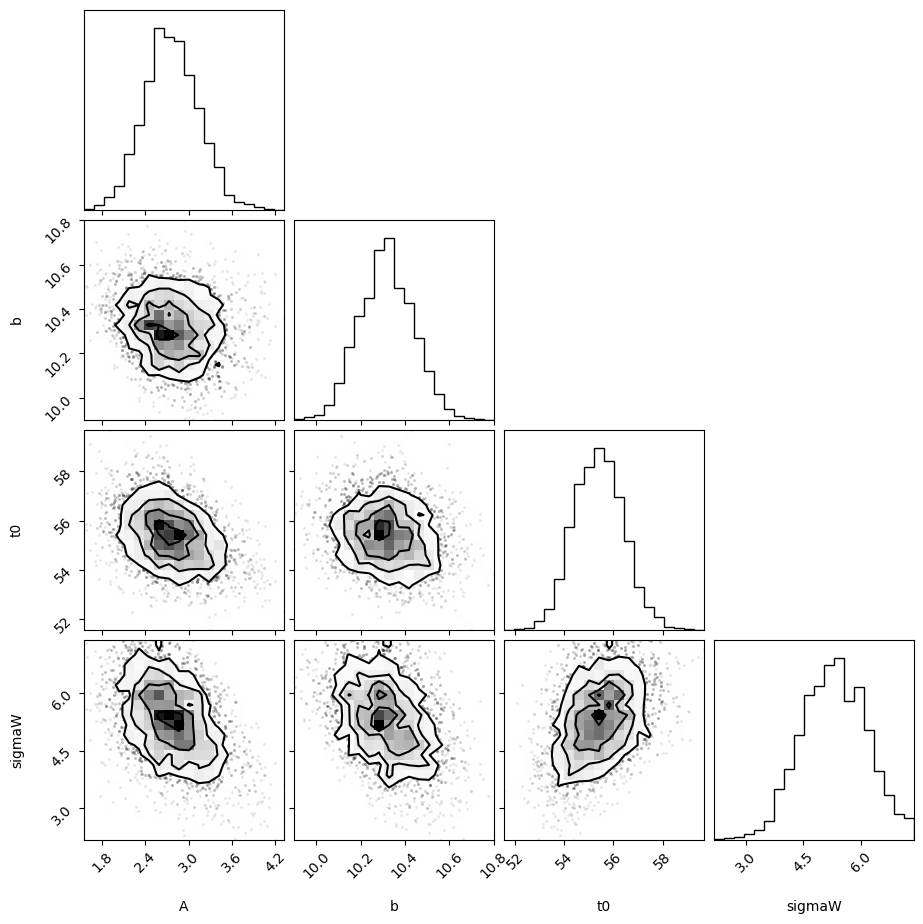

In [78]:
samples_equal = dyfunc.resample_equal(samples, weights)
labels = ["A","b","t0","sigmaW"]
corner.corner(samples_equal, labels=labels);

In [79]:
bayes_factor=np.exp(evidence)/np.exp(evidence2)
if bayes_factor > 100: print(bayes_factor,'Decisive')
elif bayes_factor > 30: print(bayes_factor,'Very strong')
elif bayes_factor > 10: print(bayes_factor,'Strong')
elif bayes_factor > 3: print(bayes_factor,'Substantial')
elif bayes_factor > 1: print(bayes_factor,'Barely worth mentioning')
else: print('Negative')

72.77031731946155 Very strong
